### **Stage1: Descriptive Statistics**

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap

# Warm-cool palette
C_2016 = '#d73221'
C_2020 = '#4573b4'
C_2016_LIGHT = '#f2724d'
C_2020_LIGHT = '#6491c1'
C_GOLD = '#fcb777'
C_CREAM = '#fde699'
C_DARK = '#2C2C2C'
C_BAR = ['#d73221', '#e35235', '#fcb777', '#6491c1', '#4573b4']

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white'
})

In [2]:
# load the data
df = pd.read_csv('GLA_Master_New.csv', encoding='utf-8-sig').copy()

# Income
df['IncRate_2020'] = df['IncRate'].str.replace('%', '').astype(float)
df['IncRate_2016'] = df['IncRate_1'] * 100
df['Inc_Change'] = df['IncRate_2020'] - df['IncRate_2016']

# NO2
df['NO2_Change'] = df['NO2_2020'] - df['NO2_2016']

# VDL
df['VDL_Change'] = df['VDL_Ratio20'] - df['VDL_Ratio16']

# Green Space (PAN65, static)
df['NoGreen'] = 1 - df['PAN_GreenRatio']

print(f"Data loaded: {len(df)} data zones")

Data loaded: 746 data zones


In [3]:
# Summary Table of Descriptive Statistics for All Indicators

indicators = {
    'Income Rate 2016 (%)': df['IncRate_2016'],
    'Income Rate 2020 (%)': df['IncRate_2020'],
    'NO₂ 2016 (µg/m³)': df['NO2_2016'],
    'NO₂ 2020 (µg/m³)': df['NO2_2020'],
    'VDL Ratio 2016': df['VDL_Ratio16'],
    'VDL Ratio 2020': df['VDL_Ratio20'],
    'Green Space Ratio (PAN65)': df['PAN_GreenRatio']
}

summary = pd.DataFrame({
    name: [s.mean(), s.median(), s.std(), s.min(), s.quantile(0.25),
           s.quantile(0.75), s.max(), s.skew()]
    for name, s in indicators.items()
}, index=['Mean', 'Median', 'Std', 'Min', 'Q1', 'Q3', 'Max', 'Skewness']).round(3)

print(summary.to_string())

          Income Rate 2016 (%)  Income Rate 2020 (%)  NO₂ 2016 (µg/m³)  NO₂ 2020 (µg/m³)  VDL Ratio 2016  VDL Ratio 2020  Green Space Ratio (PAN65)
Mean                    20.757                19.792            16.375            13.853           0.233           0.173                      0.203
Median                  20.000                19.000            16.036            13.379           0.111           0.026                      0.186
Std                     12.257                12.218             3.996             3.499           0.281           0.250                      0.108
Min                      0.000                 0.000             8.773             7.273           0.000           0.000                      0.005
Q1                      10.000                 9.000            13.843            11.689           0.000           0.000                      0.124
Q3                      30.000                29.000            17.744            15.146           0.403        

In [4]:
# Normality test+paired test (three dynamic indicators)

dynamic_pairs = [
    ('IncRate_2016', 'IncRate_2020', 'Income Rate'),
    ('NO2_2016', 'NO2_2020', 'NO₂ Concentration'),
    ('VDL_Ratio16', 'VDL_Ratio20', 'VDL Ratio')
]

print("=" * 70)
print("NORMALITY CHECK AND PAIRED TESTS (2016 vs 2020)")
print("=" * 70)

for col_16, col_20, label in dynamic_pairs:
    diff = df[col_20] - df[col_16]
    w, p_sw = stats.shapiro(diff)
    print(f"\n--- {label} ---")
    print(f"  Shapiro-Wilk: W = {w:.4f}, p = {p_sw:.4e}")
    
    if p_sw >= 0.05:
        t, p_t = stats.ttest_rel(df[col_20], df[col_16])
        print(f"  Normal distribution confirmed. Paired t-test: t = {t:.3f}, p = {p_t:.4e}")
    else:
        w_stat, p_w = stats.wilcoxon(df[col_20], df[col_16])
        print(f"  Normality not met. Wilcoxon signed-rank: W = {w_stat:.0f}, p = {p_w:.4e}")
    
    print(f"  Mean 2016: {df[col_16].mean():.3f}, Mean 2020: {df[col_20].mean():.3f}")
    print(f"  Mean change: {diff.mean():+.3f}")

NORMALITY CHECK AND PAIRED TESTS (2016 vs 2020)

--- Income Rate ---
  Shapiro-Wilk: W = 0.8694, p = 1.8446e-24
  Normality not met. Wilcoxon signed-rank: W = 65596, p = 9.7363e-16
  Mean 2016: 20.757, Mean 2020: 19.792
  Mean change: -0.965

--- NO₂ Concentration ---
  Shapiro-Wilk: W = 0.9533, p = 1.2228e-14
  Normality not met. Wilcoxon signed-rank: W = 0, p = 8.9013e-124
  Mean 2016: 16.375, Mean 2020: 13.853
  Mean change: -2.521

--- VDL Ratio ---
  Shapiro-Wilk: W = 0.7255, p = 3.0098e-33
  Normality not met. Wilcoxon signed-rank: W = 15399, p = 2.4138e-35
  Mean 2016: 0.233, Mean 2020: 0.173
  Mean change: -0.060


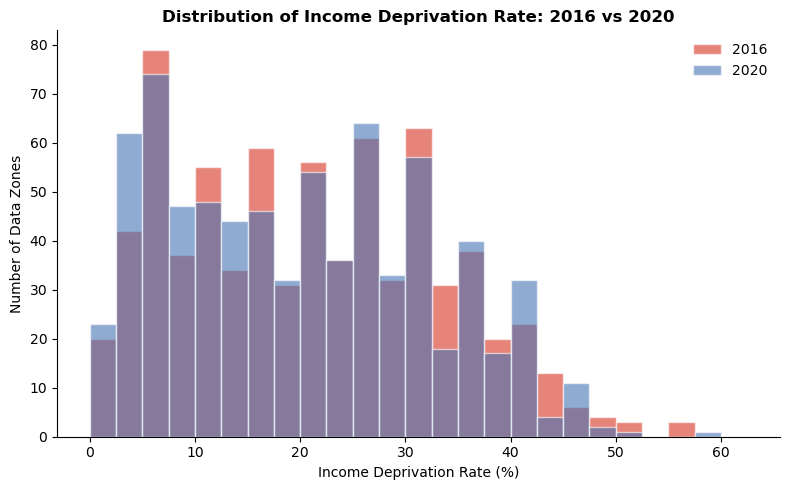

In [5]:
# Income histogram (unified bins)

bins_inc = np.arange(0, 65, 2.5)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['IncRate_2016'], bins=bins_inc, alpha=0.6, color=C_2016, label='2016', edgecolor='white')
ax.hist(df['IncRate_2020'], bins=bins_inc, alpha=0.6, color=C_2020, label='2020', edgecolor='white')
ax.set_xlabel('Income Deprivation Rate (%)')
ax.set_ylabel('Number of Data Zones')
ax.set_title('Distribution of Income Deprivation Rate: 2016 vs 2020')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

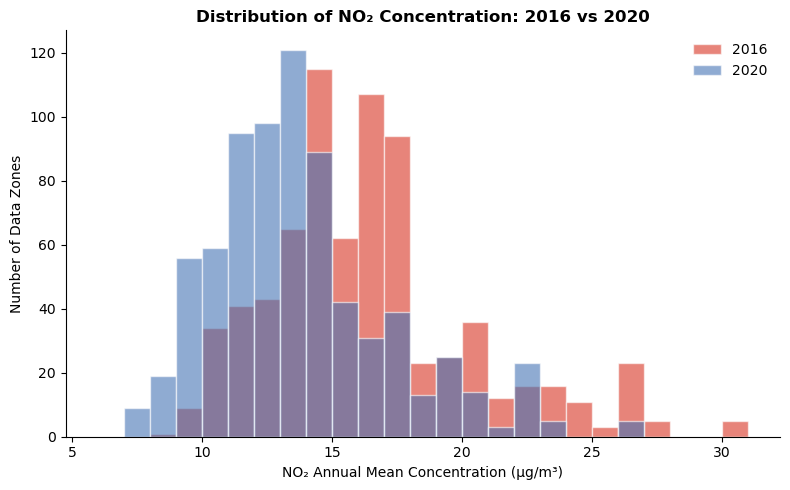

In [6]:
# NO2 histogram (unified bins)

bins_no2 = np.arange(6, 32, 1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['NO2_2016'], bins=bins_no2, alpha=0.6, color=C_2016, label='2016', edgecolor='white')
ax.hist(df['NO2_2020'], bins=bins_no2, alpha=0.6, color=C_2020, label='2020', edgecolor='white')
ax.set_xlabel('NO₂ Annual Mean Concentration (µg/m³)')
ax.set_ylabel('Number of Data Zones')
ax.set_title('Distribution of NO₂ Concentration: 2016 vs 2020')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

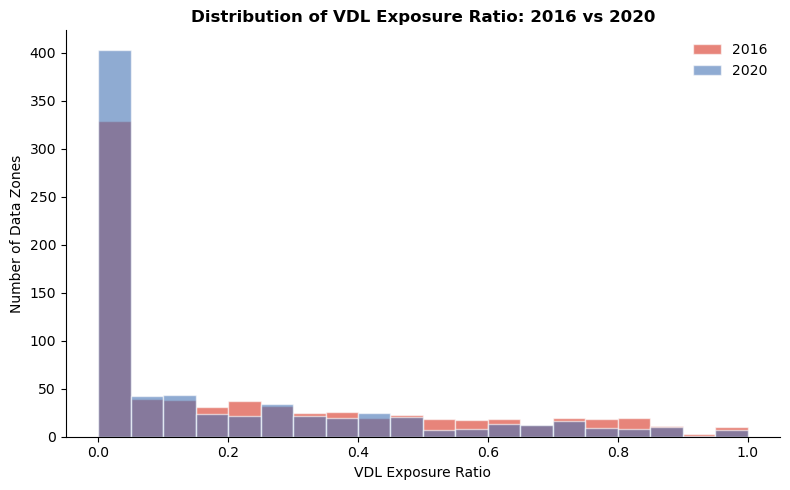

In [7]:
# VDL histogram (unified bins)

bins_vdl = np.arange(0, 1.05, 0.05)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['VDL_Ratio16'], bins=bins_vdl, alpha=0.6, color=C_2016, label='2016', edgecolor='white')
ax.hist(df['VDL_Ratio20'], bins=bins_vdl, alpha=0.6, color=C_2020, label='2020', edgecolor='white')
ax.set_xlabel('VDL Exposure Ratio')
ax.set_ylabel('Number of Data Zones')
ax.set_title('Distribution of VDL Exposure Ratio: 2016 vs 2020')
ax.legend(frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

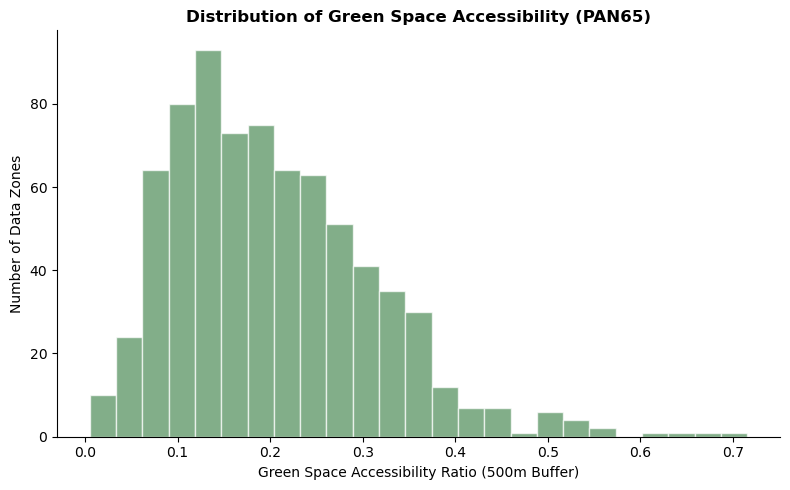

In [8]:
# Green Space histogram (single time point)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['PAN_GreenRatio'], bins=25, alpha=0.7, color='#4d8c57', edgecolor='white')
ax.set_xlabel('Green Space Accessibility Ratio (500m Buffer)')
ax.set_ylabel('Number of Data Zones')
ax.set_title('Distribution of Green Space Accessibility (PAN65)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

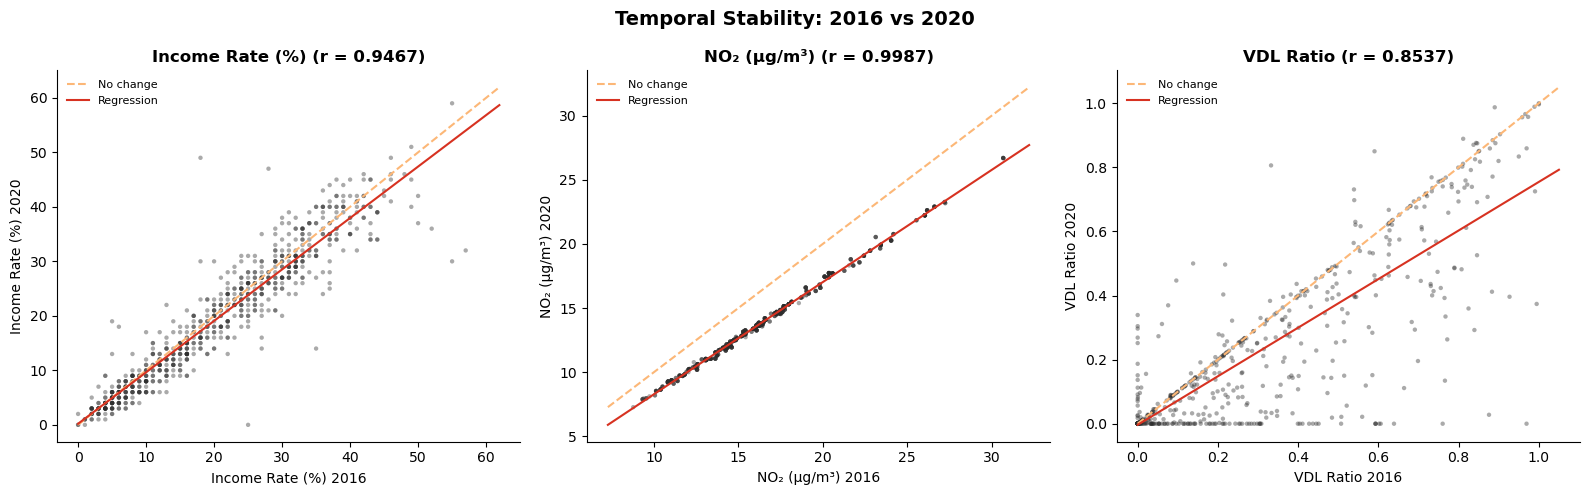

In [9]:
# 2016 vs 2020 scatter plot (three dynamic indicators together)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

scatter_pairs = [
    ('IncRate_2016', 'IncRate_2020', 'Income Rate (%)'),
    ('NO2_2016', 'NO2_2020', 'NO₂ (µg/m³)'),
    ('VDL_Ratio16', 'VDL_Ratio20', 'VDL Ratio')
]

for ax, (x, y, label) in zip(axes, scatter_pairs):
    r, _ = stats.pearsonr(df[x], df[y])
    ax.scatter(df[x], df[y], s=10, alpha=0.4, color=C_DARK, edgecolors='none')
    lim_min = min(df[x].min(), df[y].min())
    lim_max = max(df[x].max(), df[y].max()) * 1.05
    ax.plot([lim_min, lim_max], [lim_min, lim_max], '--', color=C_GOLD, linewidth=1.5, label='No change')
    z = np.polyfit(df[x], df[y], 1)
    xline = np.linspace(lim_min, lim_max, 100)
    ax.plot(xline, np.polyval(z, xline), color=C_2016, linewidth=1.5, label='Regression')
    ax.set_xlabel(f'{label} 2016')
    ax.set_ylabel(f'{label} 2020')
    ax.set_title(f'{label} (r = {r:.4f})')
    ax.legend(frameon=False, fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Temporal Stability: 2016 vs 2020', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

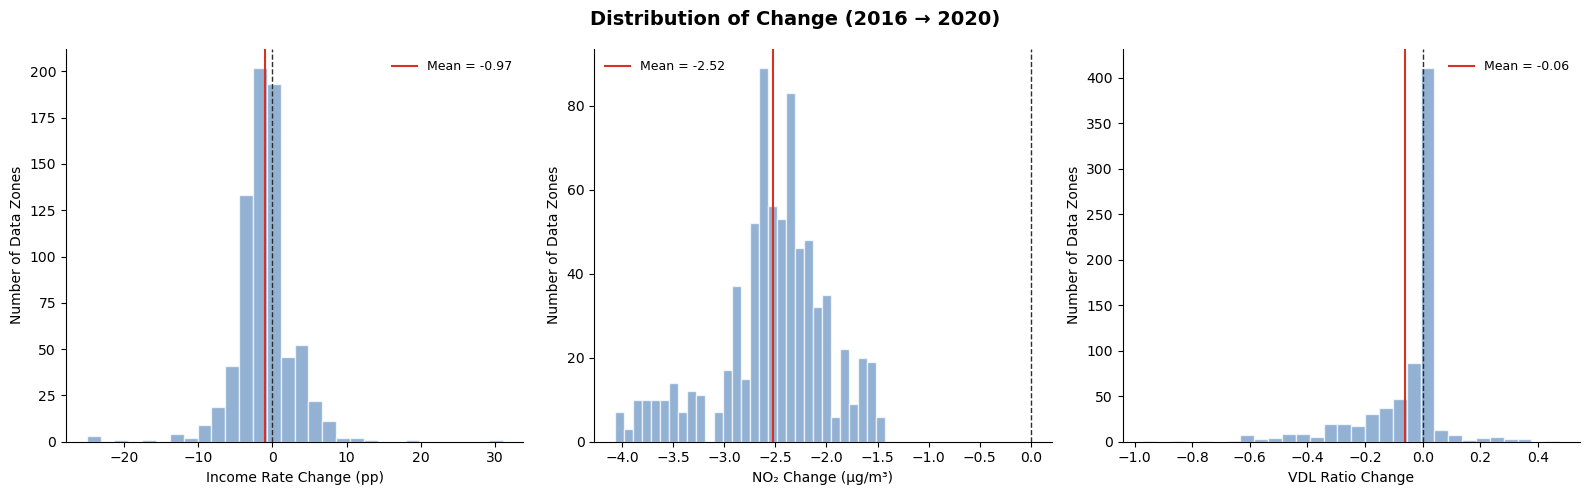

In [10]:
# Change distribution (three dynamic indicators together)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

changes = [
    (df['Inc_Change'], 'Income Rate Change (pp)', C_2020_LIGHT),
    (df['NO2_Change'], 'NO₂ Change (µg/m³)', C_2020_LIGHT),
    (df['VDL_Change'], 'VDL Ratio Change', C_2020_LIGHT)
]

for ax, (data, label, color) in zip(axes, changes):
    ax.hist(data, bins=30, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(0, color=C_DARK, linestyle='--', linewidth=1)
    ax.axvline(data.mean(), color=C_2016, linewidth=1.5, label=f'Mean = {data.mean():+.2f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Number of Data Zones')
    ax.legend(frameon=False, fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Distribution of Change (2016 → 2020)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

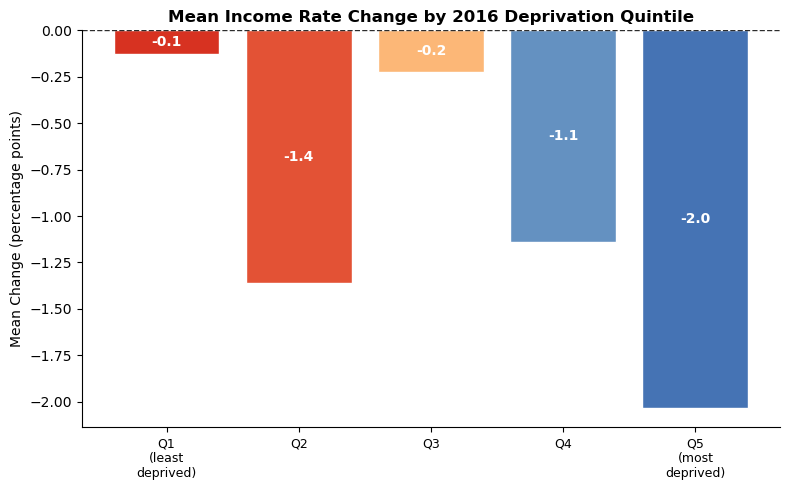

In [11]:
# Income quantile analysis

df['Quintile_2016'] = pd.qcut(df['IncRate_2016'], 5,
    labels=['Q1\n(least\ndeprived)', 'Q2', 'Q3', 'Q4', 'Q5\n(most\ndeprived)'])
quintile_change = df.groupby('Quintile_2016')['Inc_Change'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(range(5), quintile_change.values, color=C_BAR, edgecolor='white')
ax.set_xticks(range(5))
ax.set_xticklabels(quintile_change.index, fontsize=9)
ax.axhline(0, color=C_DARK, linestyle='--', linewidth=1)
ax.set_ylabel('Mean Change (percentage points)')
ax.set_title('Mean Income Rate Change by 2016 Deprivation Quintile')
ax.spines[['top', 'right']].set_visible(False)

for i, v in enumerate(quintile_change.values):
    if v >= 0:
        ax.text(i, v + 0.1, f'{v:+.1f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    else:
        ax.text(i, v / 2, f'{v:+.1f}', ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

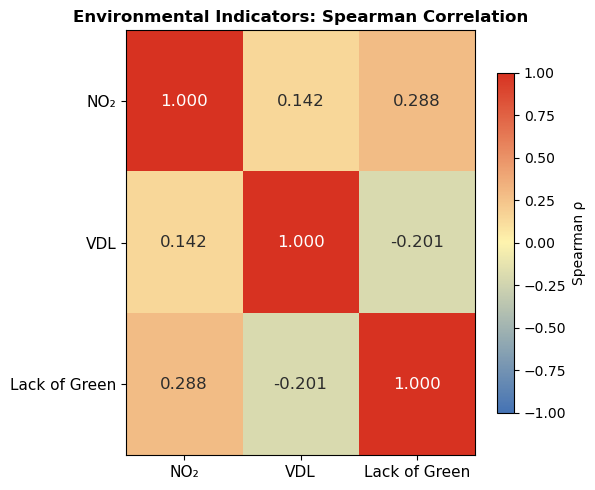

Spearman correlation tests:
  NO₂ vs VDL: ρ = 0.142, p = 1.01e-04
  NO₂ vs Lack of Green: ρ = 0.288, p = 9.88e-16
  VDL vs Lack of Green: ρ = -0.201, p = 2.97e-08


In [12]:
# Spearman correlation between environmental indicators

env_2016 = {
    'NO₂': df['NO2_2016'],
    'VDL': df['VDL_Ratio16'],
    'Lack of Green': df['NoGreen']
}

env_df = pd.DataFrame(env_2016)
spearman_matrix = env_df.corr(method='spearman')

mondrian_cmap = LinearSegmentedColormap.from_list('mondrian',
    ['#4573b4', '#fef4ae', '#d73221'])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(spearman_matrix, cmap=mondrian_cmap, vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(spearman_matrix)))
ax.set_yticks(range(len(spearman_matrix)))
ax.set_xticklabels(spearman_matrix.columns, fontsize=11)
ax.set_yticklabels(spearman_matrix.columns, fontsize=11)

for i in range(len(spearman_matrix)):
    for j in range(len(spearman_matrix)):
        val = spearman_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else C_DARK
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=12, color=color)

plt.colorbar(im, ax=ax, shrink=0.8, label='Spearman ρ')
ax.set_title('Environmental Indicators: Spearman Correlation', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Print formal test results
print("Spearman correlation tests:")
for i, c1 in enumerate(env_df.columns):
    for j, c2 in enumerate(env_df.columns):
        if i < j:
            rho, p = stats.spearmanr(env_df[c1], env_df[c2])
            print(f"  {c1} vs {c2}: ρ = {rho:.3f}, p = {p:.2e}")

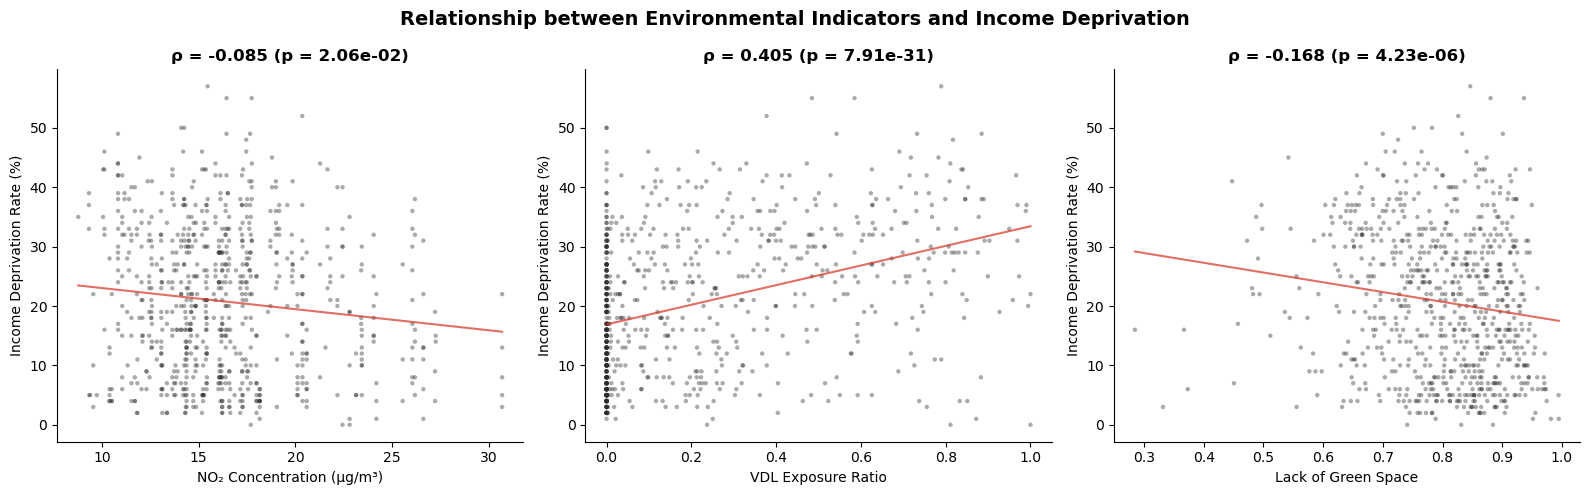

In [15]:
# Environmental indicators vs. Income scatter plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

env_pairs = [
    ('NO2_2016', 'NO₂ Concentration (µg/m³)'),
    ('VDL_Ratio16', 'VDL Exposure Ratio'),
    ('NoGreen', 'Lack of Green Space')
]

for ax, (var, xlabel) in zip(axes, env_pairs):
    rho, p = stats.spearmanr(df[var], df['IncRate_2016'])
    ax.scatter(df[var], df['IncRate_2016'], s=10, alpha=0.4, color=C_DARK, edgecolors='none')
    z = np.polyfit(df[var], df['IncRate_2016'], 1)
    xline = np.linspace(df[var].min(), df[var].max(), 100)
    ax.plot(xline, np.polyval(z, xline), color=C_2016, linewidth=1.5, alpha=0.7)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Income Deprivation Rate (%)')
    ax.set_title(f'ρ = {rho:.3f} (p = {p:.2e})')
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Relationship between Environmental Indicators and Income Deprivation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

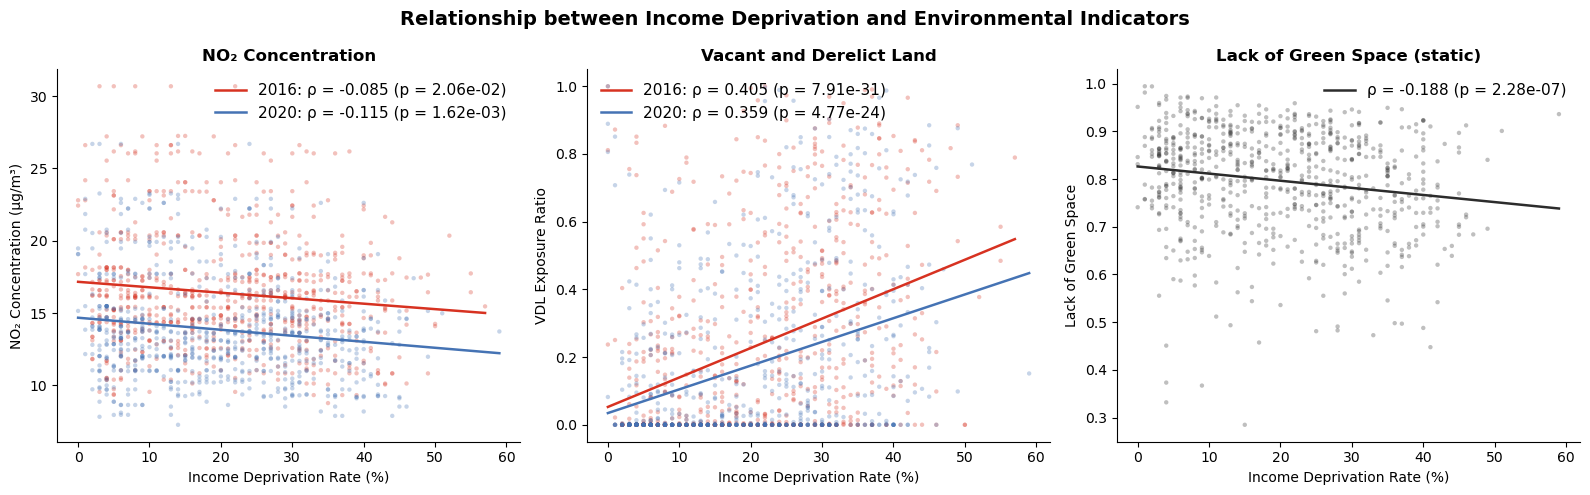

In [17]:
# Environmental indicators vs. Income scatter plot (updated)
# Income deprivation on x-axis (independent variable)
# Both 2016 and 2020 shown for NO₂ and VDL
# Green space: single time point only

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: NO₂ (two years)
ax = axes[0]
for year, inc_col, env_col, color, label in [
    (2016, 'IncRate_2016', 'NO2_2016', C_2016, '2016'),
    (2020, 'IncRate_2020', 'NO2_2020', C_2020, '2020')
]:
    rho, p = stats.spearmanr(df[inc_col], df[env_col])
    ax.scatter(df[inc_col], df[env_col], s=10, alpha=0.3, color=color, edgecolors='none')
    z = np.polyfit(df[inc_col], df[env_col], 1)
    xline = np.linspace(df[inc_col].min(), df[inc_col].max(), 100)
    ax.plot(xline, np.polyval(z, xline), color=color, linewidth=1.8,
            label=f'{label}: ρ = {rho:.3f} (p = {p:.2e})')

ax.set_xlabel('Income Deprivation Rate (%)')
ax.set_ylabel('NO₂ Concentration (µg/m³)')
ax.set_title('NO₂ Concentration')
ax.legend(fontsize=11, frameon=False, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)

# Panel 2: VDL (two years)
ax = axes[1]
for year, inc_col, env_col, color, label in [
    (2016, 'IncRate_2016', 'VDL_Ratio16', C_2016, '2016'),
    (2020, 'IncRate_2020', 'VDL_Ratio20', C_2020, '2020')
]:
    rho, p = stats.spearmanr(df[inc_col], df[env_col])
    ax.scatter(df[inc_col], df[env_col], s=10, alpha=0.3, color=color, edgecolors='none')
    z = np.polyfit(df[inc_col], df[env_col], 1)
    xline = np.linspace(df[inc_col].min(), df[inc_col].max(), 100)
    ax.plot(xline, np.polyval(z, xline), color=color, linewidth=1.8,
            label=f'{label}: ρ = {rho:.3f} (p = {p:.2e})')

ax.set_xlabel('Income Deprivation Rate (%)')
ax.set_ylabel('VDL Exposure Ratio')
ax.set_title('Vacant and Derelict Land')
ax.legend(fontsize=11, frameon=False, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

# Panel 3: Green space (single year)
ax = axes[2]
rho, p = stats.spearmanr(df['IncRate_2020'], df['NoGreen'])
ax.scatter(df['IncRate_2020'], df['NoGreen'], s=10, alpha=0.3, color=C_DARK, edgecolors='none')
z = np.polyfit(df['IncRate_2020'], df['NoGreen'], 1)
xline = np.linspace(df['IncRate_2020'].min(), df['IncRate_2020'].max(), 100)
ax.plot(xline, np.polyval(z, xline), color=C_DARK, linewidth=1.8,
        label=f'ρ = {rho:.3f} (p = {p:.2e})')

ax.set_xlabel('Income Deprivation Rate (%)')
ax.set_ylabel('Lack of Green Space')
ax.set_title('Lack of Green Space (static)')
ax.legend(fontsize=11, frameon=False, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Relationship between Income Deprivation and Environmental Indicators',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [1]:
import subprocess
subprocess.run(['jupyter', 'nbconvert', '--to', 'html', 'Descriptive_Statistics.ipynb'])

CompletedProcess(args=['jupyter', 'nbconvert', '--to', 'html', 'Descriptive_Statistics.ipynb'], returncode=0)